In [3]:
import numpy
import ot
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_2d_gaussian_samples(mean, std, num_samples):
    mean = np.array(mean).reshape(2)
    if np.isscalar(std):
        cov = np.eye(2) * std**2
    else:
        cov = np.diag(np.array(std)**2)
    
    samples = np.random.multivariate_normal(mean, cov, num_samples)
    return samples

In [40]:
mean_a = [0, 0]
std_a = [5.0, 1.0]
num_samples_a = 20
samples_A = generate_2d_gaussian_samples(mean_a, std_a, num_samples_a)

mean_b = [10, 10]
std_b = [1.0, 2.0]
num_samples_b = 25
samples_B = generate_2d_gaussian_samples(mean_b, std_b, num_samples_b)

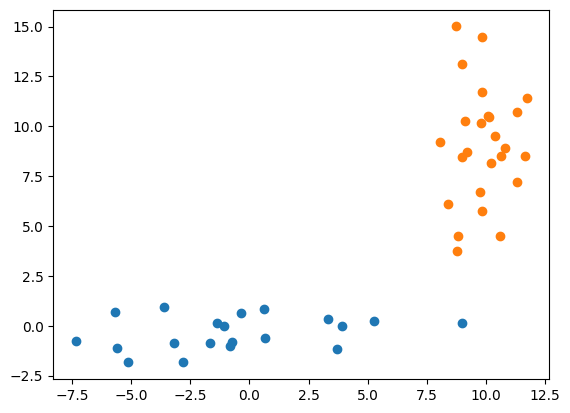

In [41]:
plt.scatter(samples_A[:, 0], samples_A[:, 1])
plt.scatter(samples_B[:, 0], samples_B[:, 1])

In [82]:
mu = np.array([1.0 / num_samples_a] * num_samples_a)
nu = np.array([1.0 / num_samples_b] * num_samples_b)

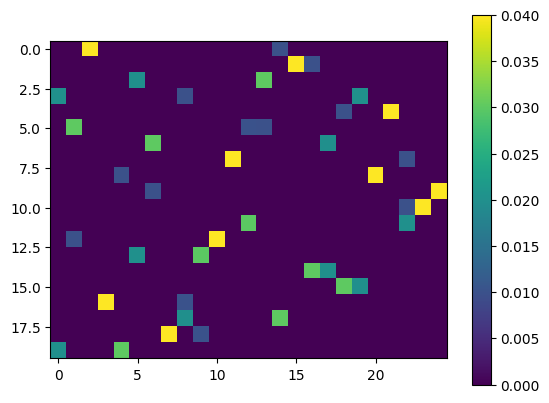

In [83]:
P = ot.emd(a=mu, b=nu, M=ot.dist(samples_A, samples_B))
plt.imshow(P)
plt.colorbar()
plt.show()

In [98]:
n_samples = num_samples_a + num_samples_b
barycenter = ot.bregman.free_support_sinkhorn_barycenter(
    measures_locations=[samples_A, samples_B],
    measures_weights=[mu, nu],
    reg=1e-3,
    verbose=True,
    X_init=np.random.randn(n_samples, 2),
    b=np.array([1.0 / n_samples] * n_samples),
    method='sinkhorn_log'
)

iteration %d, displacement_square_norm=%f
 0 1244.4426090824688
iteration %d, displacement_square_norm=%f
 1 209.06120992164387
iteration %d, displacement_square_norm=%f
 2 94.68643445219837
iteration %d, displacement_square_norm=%f
 3 13.88141235450049
iteration %d, displacement_square_norm=%f
 4 6.518645429840991
iteration %d, displacement_square_norm=%f
 5 1.1131426149710921
iteration %d, displacement_square_norm=%f
 6 0.11893339614002704
iteration %d, displacement_square_norm=%f
 7 0.520430561697252
iteration %d, displacement_square_norm=%f
 8 4.0997447268311297e-22


In [102]:
barycenter.shape

(45, 2)

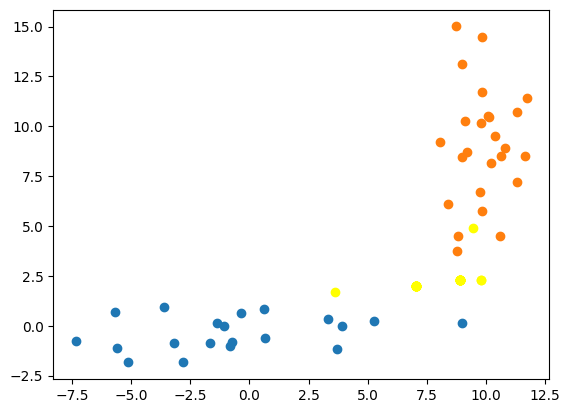

In [103]:
plt.scatter(barycenter[:, 0], barycenter[:, 1], c='yellow')
plt.scatter(samples_A[:, 0], samples_A[:, 1])
plt.scatter(samples_B[:, 0], samples_B[:, 1])
plt.show()

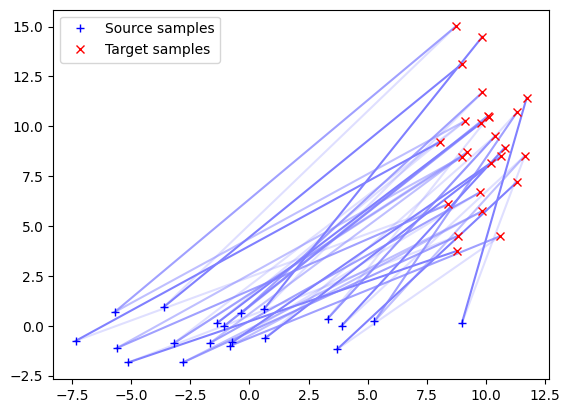

In [104]:
import ot.plot
ot.plot.plot2D_samples_mat(samples_A, samples_B, P, color=[0.5, 0.5, 1])
plt.plot(samples_A[:, 0], samples_A[:, 1], "+b", label="Source samples")
plt.plot(samples_B[:, 0], samples_B[:, 1], "xr", label="Target samples")
plt.legend(loc=0)
plt.show()

In [194]:
import ot.mapping
import matplotlib.pyplot as pl

Xs_new = generate_2d_gaussian_samples(mean_a, std_a, num_samples_a)
Xs = samples_A
Xt = samples_B

# MappingTransport with linear kernel
ot_mapping_linear = ot.da.MappingTransport(
    kernel="linear", mu=1e0, eta=1e-8, bias=True, max_iter=20, verbose=True
)

ot_mapping_linear.fit(Xs=Xs, Xt=Xt)

# for original source samples, transform applies barycentric mapping
transp_Xs_linear = ot_mapping_linear.transform(Xs=Xs)

# for out of source samples, transform applies the linear mapping
transp_Xs_linear_new = ot_mapping_linear.transform(Xs=Xs_new)


# MappingTransport with gaussian kernel
ot_mapping_gaussian = ot.da.MappingTransport(
    kernel="gaussian", eta=1e-5, mu=1e-1, bias=True, sigma=1, max_iter=10, verbose=True
)
ot_mapping_gaussian.fit(Xs=Xs, Xt=Xt)

# for original source samples, transform applies barycentric mapping
transp_Xs_gaussian = ot_mapping_gaussian.transform(Xs=Xs)

# for out of source samples, transform applies the gaussian mapping
transp_Xs_gaussian_new = ot_mapping_gaussian.transform(Xs=Xs_new)

It.  |Loss        |Delta loss
--------------------------------
    0|4.280484e+03|0.000000e+00
    1|4.271295e+03|-2.146600e-03
    2|4.270462e+03|-1.952022e-04
    3|4.270191e+03|-6.346347e-05
    4|4.270067e+03|-2.891686e-05
    5|4.270036e+03|-7.344658e-06
It.  |Loss        |Delta loss
--------------------------------
    0|4.265780e+02|0.000000e+00
    1|4.265780e+02|0.000000e+00


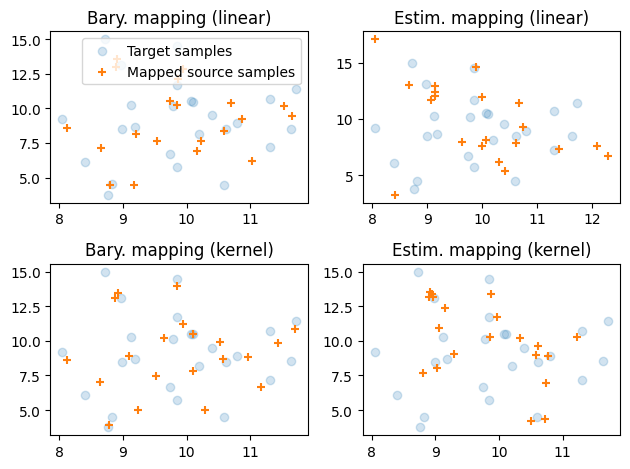

In [196]:
pl.figure(2)
pl.clf()
pl.subplot(2, 2, 1)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_linear[:, 0],
    transp_Xs_linear[:, 1],
    marker="+",
    label="Mapped source samples",
)
pl.title("Bary. mapping (linear)")
pl.legend(loc=0)

pl.subplot(2, 2, 2)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_linear_new[:, 0],
    transp_Xs_linear_new[:, 1],
    marker="+",
    label="Learned mapping",
)
pl.title("Estim. mapping (linear)")

pl.subplot(2, 2, 3)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_gaussian[:, 0],
    transp_Xs_gaussian[:, 1],
    marker="+",
    label="barycentric mapping",
)
pl.title("Bary. mapping (kernel)")

pl.subplot(2, 2, 4)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_gaussian_new[:, 0],
    transp_Xs_gaussian_new[:, 1],
    marker="+",
    label="Learned mapping",
)
pl.title("Estim. mapping (kernel)")
pl.tight_layout()

pl.show()

In [190]:
k = ot.mapping.kernel(samples_A, samples_A, sigma=1.0)
transported_source = np.dot(k, samples_A)

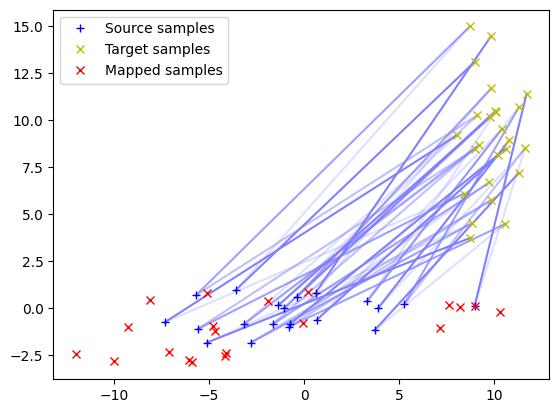

In [191]:
import ot.plot
ot.plot.plot2D_samples_mat(samples_A, samples_B, P, color=[0.5, 0.5, 1])
plt.plot(samples_A[:, 0], samples_A[:, 1], "+b", label="Source samples")
plt.plot(samples_B[:, 0], samples_B[:, 1], "xy", label="Target samples")
plt.plot(transported_source[:, 0], transported_source[:, 1], "xr", label="Mapped samples")
plt.legend(loc=0)
plt.show()

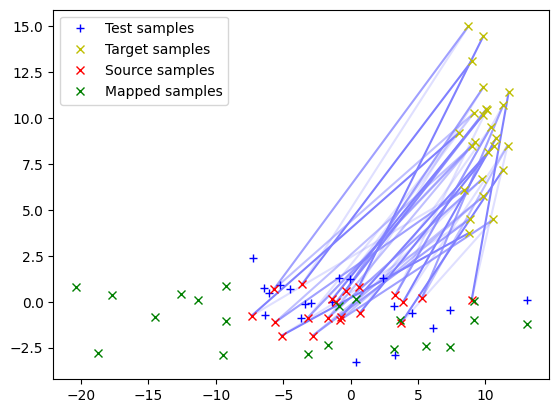

In [192]:

kernel = ot.mapping.kernel(test_samples, test_samples, sigma=1.0)
transported_test = np.dot(kernel, test_samples)
ot.plot.plot2D_samples_mat(samples_A, samples_B, G, color=[0.5, 0.5, 1])
plt.plot(test_samples[:, 0], test_samples[:, 1], "+b", label="Test samples")
plt.plot(samples_B[:, 0], samples_B[:, 1], "xy", label="Target samples")
plt.plot(samples_A[:, 0], samples_A[:, 1], "xr", label="Source samples")
plt.plot(transported_test[:, 0], transported_source[:, 1], "xg", label="Mapped samples")
plt.legend(loc=0)
plt.show()